# Unified media — OCR v2 (filename, station, time + 2024/2025 validation)

## Goal
Process **`unified_media/unified_manifest.csv`** and produce a clean table with:
- **`filename`** — basename of the unified raster
- **`station_id`** — grid/site id from the manifest (same as `station_raw` in most cases)
- **Timestamps** — derived with a **new strategy** that reduces false 2026 copy-time artifacts:
  1. Read **EXIF** from the **original** file (`source_path`) first.
  2. If EXIF year is **2024 or 2025** → use EXIF as **`ts_final`** and **skip OCR** (saves time).
  3. Otherwise → run **OCR** on a **bottom strip** of the **unified** image (`unified_path`) and merge with EXIF using the rules below.

## Output
- `eda_outputs/unified_media_ocr_v2.csv`

## Notes
- All code stays in this notebook (no extra `.py` files).
- Tune `BOTTOM_STRIP_FRAC`, `LIMIT_ROWS`, or OCR settings if coverage is low.


In [1]:
%pip -q install opencv-python pillow pandas tqdm matplotlib easyocr pytesseract python-dateutil


Note: you may need to restart the kernel to use updated packages.


In [2]:
from __future__ import annotations

import re
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from dateutil import parser as dt_parser

import easyocr

REPO = Path("/home/chengwei/boartraining/HackMITChina2026").resolve()
UNIFIED_MANIFEST = REPO / "unified_media" / "unified_manifest.csv"
OUT_DIR = REPO / "eda_outputs"
OUT_CSV = OUT_DIR / "unified_media_ocr_v2.csv"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Ecological time window (camera deployment / field season)
EXPECTED_YEARS = {2024, 2025}
SUSPECT_COPY_YEAR = 2026

# OCR: only bottom strip of unified image (fraction of height from bottom)
BOTTOM_STRIP_FRAC = 0.18  # e.g. last 18% of image height

print("UNIFIED_MANIFEST:", UNIFIED_MANIFEST)
print("OUT_CSV:", OUT_CSV)
print("EXPECTED_YEARS:", sorted(EXPECTED_YEARS))


UNIFIED_MANIFEST: /home/chengwei/boartraining/HackMITChina2026/unified_media/unified_manifest.csv
OUT_CSV: /home/chengwei/boartraining/HackMITChina2026/eda_outputs/unified_media_ocr_v2.csv
EXPECTED_YEARS: [2024, 2025]


## 1) Load manifest

Each row points to a raster under `unified_media/images/` via **`unified_path`** and the original capture file via **`source_path`**.


In [3]:
df = pd.read_csv(UNIFIED_MANIFEST, low_memory=False)
need = {"unified_path", "source_path", "station_id"}
miss = need - set(df.columns)
if miss:
    raise ValueError(f"Manifest missing columns: {miss}")

df["filename"] = df["unified_path"].map(lambda p: Path(str(p)).name)
df["station_id"] = df["station_id"].astype(str).str.strip()

print("rows:", len(df))
df[["filename", "station_id", "unified_path"]].head()


rows: 25701


,filename,station_id,unified_path
0,B1__img__c14a239d4be0__IMG_0062.jpg,B1,/home/chengwei/boartraining/HackMITChina2026/u...
1,B1__img__efaf9a2cb2bf__IMG_0057.jpg,B1,/home/chengwei/boartraining/HackMITChina2026/u...
2,B1__img__9abcb6d01f91__IMG_0031.jpg,B1,/home/chengwei/boartraining/HackMITChina2026/u...
3,B1__img__0c76a03af4f4__IMG_0039.jpg,B1,/home/chengwei/boartraining/HackMITChina2026/u...
4,B1__img__618a041f30fd__IMG_0021.jpg,B1,/home/chengwei/boartraining/HackMITChina2026/u...


## 2) EXIF from original `source_path`

Uses `DateTimeOriginal` then `DateTime` when present. This often reflects true shutter time even when the unified copy has a recent filesystem mtime.


In [4]:
from PIL import Image

TAG_DT_ORIGINAL = 36867
TAG_DT = 306


def read_exif_ts(path_str: str) -> pd.Timestamp | None:
    p = Path(path_str)
    if not p.is_file():
        return None
    suf = p.suffix.lower()
    if suf not in {".jpg", ".jpeg", ".tif", ".tiff", ".heic", ".heif"}:
        return None
    try:
        with Image.open(p) as im:
            exif = im.getexif()
            raw = exif.get(TAG_DT_ORIGINAL) or exif.get(TAG_DT)
    except Exception:
        return None
    if raw is None:
        return None
    if isinstance(raw, bytes):
        raw = raw.decode(errors="ignore")
    if isinstance(raw, str):
        raw = raw.strip().replace(":", "-", 2)
    t = pd.to_datetime(raw, errors="coerce")
    if pd.isna(t):
        return None
    try:
        if t.tzinfo is not None:
            t = pd.Timestamp(t.value)
    except Exception:
        return None
    return t


print("EXIF helper ready.")


EXIF helper ready.


## 3) Bottom-strip OCR on `unified_path`

Compared with a full multi-ROI sweep, this notebook uses **one primary crop** (bottom strip) to reduce conflicting OCR reads and speed up processing. **`parse_ts_overlay`** follows the same date+time pairing logic as the previous pipeline’s robust parser.


In [5]:
import torch

EASY_OCR_LANGS = ["en"]
try:
    if torch.cuda.is_available():
        easy_reader = easyocr.Reader(EASY_OCR_LANGS, gpu=True)
        print("EasyOCR GPU:", torch.cuda.get_device_name(0))
    else:
        easy_reader = easyocr.Reader(EASY_OCR_LANGS, gpu=False)
        print("EasyOCR CPU")
except Exception as e:
    easy_reader = None
    print("EasyOCR init failed:", repr(e))


def preprocess_strip(gray: np.ndarray) -> np.ndarray:
    scale = 2
    h, w = gray.shape[:2]
    g2 = cv2.resize(gray, (w * scale, h * scale), interpolation=cv2.INTER_CUBIC)
    g2 = cv2.GaussianBlur(g2, (3, 3), 0)
    _, th = cv2.threshold(g2, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return th


def ocr_bottom_strip(path_str: str) -> tuple[str | None, float | None]:
    p = Path(path_str)
    if not p.is_file():
        return None, None
    img = cv2.imread(str(p))
    if img is None:
        return None, None
    h, w = img.shape[:2]
    y0 = max(0, int(h * (1.0 - BOTTOM_STRIP_FRAC)))
    crop = img[y0:h, :]
    if crop.size == 0:
        return None, None
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    proc = preprocess_strip(gray)
    proc_rgb = cv2.cvtColor(proc, cv2.COLOR_GRAY2RGB)
    if easy_reader is None:
        return None, None
    try:
        out = easy_reader.readtext(proc_rgb, detail=1, paragraph=False)
        lines = [r[1] for r in out if len(r) >= 2]
        confs = [float(r[2]) for r in out if len(r) >= 3]
        txt = "\n".join(lines)
        mx = float(np.max(confs)) if confs else None
        return (txt if txt.strip() else None), mx
    except Exception:
        return None, None


def parse_ts_overlay(raw_text: str | None) -> pd.Timestamp | None:
    if not raw_text or not str(raw_text).strip():
        return None
    txt = str(raw_text).replace("|", " ").strip()
    date_rx = re.compile(r"(\d{4})[\-/.]\s*(\d{1,2})[\-/.]\s*(\d{1,2})")
    time_hms_rx = re.compile(r"(\d{1,2})[\.:](\d{1,2})[\.:](\d{1,2})")
    time_hm_rx = re.compile(r"(\d{1,2})[\.:](\d{1,2})")
    for m_date in date_rx.finditer(txt):
        year, mo, da = int(m_date.group(1)), int(m_date.group(2)), int(m_date.group(3))
        after = txt[m_date.end() :]
        for m_time in time_hms_rx.finditer(after):
            hh, mm, ss = int(m_time.group(1)), int(m_time.group(2)), int(m_time.group(3))
            if not (0 <= hh <= 23 and 0 <= mm <= 59 and 0 <= ss <= 59):
                continue
            try:
                dt = dt_parser.parse(f"{year}-{mo:02d}-{da:02d} {hh:02d}:{mm:02d}:{ss:02d}")
                return pd.Timestamp(dt)
            except Exception:
                continue
        for m_time in time_hm_rx.finditer(after):
            hh, mm = int(m_time.group(1)), int(m_time.group(2))
            if not (0 <= hh <= 23 and 0 <= mm <= 59):
                continue
            try:
                dt = dt_parser.parse(f"{year}-{mo:02d}-{da:02d} {hh:02d}:{mm:02d}:00")
                return pd.Timestamp(dt)
            except Exception:
                continue
    try:
        return pd.Timestamp(dt_parser.parse(txt, fuzzy=True))
    except Exception:
        return None


print("OCR bottom-strip + parser ready.")


EasyOCR GPU: NVIDIA RTX A6000
OCR bottom-strip + parser ready.


## 4) Merge + validation (focus on 2024–2025)

**`ts_final`** selection order:
1. **EXIF first:** if EXIF year ∈ **`EXPECTED_YEARS` {2024, 2025}** → **`ts_final` = EXIF** and **do not run OCR** (`ok_exif_expected_years_skip_ocr`).
2. **Otherwise** (no EXIF or EXIF year ∉ window) → run **bottom-strip OCR**, then:
   - If OCR year ∈ **`EXPECTED_YEARS`** → use OCR (`ok_ocr_expected_years`).
   - Else if OCR year is **`SUSPECT_COPY_YEAR`** and EXIF is present with a different year → prefer EXIF (`replaced_suspect_ocr_with_exif`).
   - Else if EXIF exists → use EXIF (`exif_only_outside_window`).
   - Else if OCR exists → use OCR (`ocr_only_review`).
   - Else → missing (`missing_time`).

**`validation_status`** summarises the decision for QA.


In [6]:
def year_of(ts: pd.Timestamp | None) -> int | None:
    if ts is None or pd.isna(ts):
        return None
    try:
        return int(pd.Timestamp(ts).year)
    except Exception:
        return None


def select_final_ts(ts_ocr: pd.Timestamp | None, ts_exif: pd.Timestamp | None) -> tuple[pd.Timestamp | None, str]:
    """Used only when EXIF year is NOT in EXPECTED_YEARS (OCR was run)."""
    yo, ye = year_of(ts_ocr), year_of(ts_exif)
    if yo in EXPECTED_YEARS:
        return ts_ocr, "ok_ocr_expected_years"
    if yo == SUSPECT_COPY_YEAR and ye is not None and ye != SUSPECT_COPY_YEAR:
        return ts_exif, "replaced_suspect_ocr_with_exif"
    if ts_exif is not None and not pd.isna(ts_exif):
        return ts_exif, "exif_only_outside_window"
    if ts_ocr is not None and not pd.isna(ts_ocr):
        return ts_ocr, "ocr_only_review"
    return None, "missing_time"


print("Validation rules ready.")


Validation rules ready.


In [7]:
LIMIT_ROWS = None  # e.g. 500 for testing; None = all rows

work = df if LIMIT_ROWS is None else df.head(int(LIMIT_ROWS)).copy()

rows_out = []
for _, r in tqdm(work.iterrows(), total=len(work)):
    up = str(r["unified_path"])
    sp = str(r["source_path"])
    fn = str(r["filename"])
    st = str(r["station_id"])

    ts_exif = read_exif_ts(sp)
    ye = year_of(ts_exif)

    if ye in EXPECTED_YEARS:
        ts_final = ts_exif
        vstatus = "ok_exif_expected_years_skip_ocr"
        ts_ocr = None
        raw = None
        ocr_conf = None
        ocr_skipped = True
    else:
        ocr_skipped = False
        raw, ocr_conf = ocr_bottom_strip(up)
        ts_ocr = parse_ts_overlay(raw)
        ts_final, vstatus = select_final_ts(ts_ocr, ts_exif)

    rows_out.append(
        {
            "filename": fn,
            "station_id": st,
            "ts_ocr": ts_ocr,
            "ts_exif": ts_exif,
            "ts_final": ts_final,
            "validation_status": vstatus,
            "ocr_skipped": ocr_skipped,
            "ocr_year": year_of(ts_ocr),
            "exif_year": year_of(ts_exif),
            "final_year": year_of(ts_final),
            "ocr_conf_max": ocr_conf,
            "ocr_raw_bottom": raw,
            "unified_path": up,
            "source_path": sp,
        }
    )

out = pd.DataFrame(rows_out)
out.to_csv(OUT_CSV, index=False)
print("Saved:", OUT_CSV, "shape:", out.shape)
out.head(10)


  0%|          | 0/25701 [00:00<?, ?it/s]

/home/chengwei/Software_Engineering/.conda/lib/python3.11/site-packages/dateutil/parser/_parser.py:1207: UnknownTimezoneWarning: tzname C identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  warnings.warn("tzname {tzname} identified but not understood.  "
/home/chengwei/Software_Engineering/.conda/lib/python3.11/site-packages/dateutil/parser/_parser.py:1207: UnknownTimezoneWarning: tzname PIR identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  warnings.warn("tzname {tzname} identified but not understood.  "
Corrupt JPEG data: 328 extraneous bytes before marker 0x98
Corrupt JPEG data: 407 extraneous bytes before marker 0x2a
/home/chengwei/Software_Engineering/.conda/lib/python3.11/site-packages/dateutil/parser/_parser.py:1207: UnknownTimezoneWarning: tzname O iden

Saved: /home/chengwei/boartraining/HackMITChina2026/eda_outputs/unified_media_ocr_v2.csv shape: (25701, 14)


,filename,station_id,ts_ocr,ts_exif,ts_final,validation_status,ocr_skipped,ocr_year,exif_year,final_year,ocr_conf_max,ocr_raw_bottom,unified_path,source_path
0,B1__img__c14a239d4be0__IMG_0062.jpg,B1,None,NaT,None,missing_time,False,NaN,NaN,NaN,0.999978,UVision\n2024-10-25\n15*36*37\n023\n24*\nPIR,/home/chengwei/boartraining/HackMITChina2026/u...,/home/chengwei/boartraining/HackMITChina2026/a...
1,B1__img__efaf9a2cb2bf__IMG_0057.jpg,B1,2024-10-18 06:48:00,NaT,2024-10-18 06:48:00,ok_ocr_expected_years,False,2024.0,NaN,2024.0,0.999876,UlVision\n2024-10-18\n14*06:48 016\n281C\nPA,/home/chengwei/boartraining/HackMITChina2026/u...,/home/chengwei/boartraining/HackMITChina2026/a...
2,B1__img__9abcb6d01f91__IMG_0031.jpg,B1,None,NaT,None,missing_time,False,NaN,NaN,NaN,0.969279,Iision\n2024-10-18 13*56.55\n16\n20C\nPA,/home/chengwei/boartraining/HackMITChina2026/u...,/home/chengwei/boartraining/HackMITChina2026/a...
3,B1__img__0c76a03af4f4__IMG_0039.jpg,B1,None,NaT,None,missing_time,False,NaN,NaN,NaN,0.999937,lision\n2024-10-18\n13*58.53\nD16\n20*\nPR,/home/chengwei/boartraining/HackMITChina2026/u...,/home/chengwei/boartraining/HackMITChina2026/a...
4,B1__img__618a041f30fd__IMG_0021.jpg,B1,2024-10-11 06:16:00,NaT,2024-10-11 06:16:00,ok_ocr_expected_years,False,2024.0,NaN,2024.0,0.999960,UVision\n2024-10-11\n06.16*23 09\n21*\nPR,/home/chengwei/boartraining/HackMITChina2026/u...,/home/chengwei/boartraining/HackMITChina2026/a...
5,B1__img__0d64e758fe99__IMG_0001.jpg,B1,None,NaT,None,missing_time,False,NaN,NaN,NaN,0.993074,U@Vision\n2024-09-25 10*59*22 {023\n261\nMMI\n...,/home/chengwei/boartraining/HackMITChina2026/u...,/home/chengwei/boartraining/HackMITChina2026/a...
6,B1__img__cc4c7620d48a__IMG_0019.jpg,B1,2024-10-11 06:11:57,NaT,2024-10-11 06:11:57,ok_ocr_expected_years,False,2024.0,NaN,2024.0,0.951128,UOVision\n2024-10-11\n06.11:57 09\n211\nPia,/home/chengwei/boartraining/HackMITChina2026/u...,/home/chengwei/boartraining/HackMITChina2026/a...
7,B1__img__41cd908dffbd__IMG_0067.jpg,B1,2024-10-25 15:37:34,NaT,2024-10-25 15:37:34,ok_ocr_expected_years,False,2024.0,NaN,2024.0,0.915904,UVision\n2024-10-25\n15.37.34 023\n25C\nPr,/home/chengwei/boartraining/HackMITChina2026/u...,/home/chengwei/boartraining/HackMITChina2026/a...
8,B1__img__f9e217578f9d__IMG_0060.jpg,B1,None,NaT,None,missing_time,False,NaN,NaN,NaN,0.999218,NVicinn\n2024-10-25\n15*36:08\n023\n24C\nPIR,/home/chengwei/boartraining/HackMITChina2026/u...,/home/chengwei/boartraining/HackMITChina2026/a...
9,B1__img__bc57671db86c__IMG_0047.jpg,B1,2024-10-18 14:01:00,NaT,2024-10-18 14:01:00,ok_ocr_expected_years,False,2024.0,NaN,2024.0,0.991748,UVision\n2024-10-18\n14.01*02\nO16\n20*C\nPIA,/home/chengwei/boartraining/HackMITChina2026/u...,/home/chengwei/boartraining/HackMITChina2026/a...


OCR skipped (EXIF year in {2024,2025}): 12716 / 25701
validation_status:
validation_status
ok_exif_expected_years_skip_ocr    12716
ok_ocr_expected_years               6770
missing_time                        4685
exif_only_outside_window            1119
ocr_only_review                      411
Name: count, dtype: int64

final_year counts:
final_year
733.0         1
2016.0        1
2021.0     1163
2023.0      327
2024.0     8683
2025.0    10803
2026.0        4
2035.0        1
2041.0        1
2074.0        1
2088.0        1
2125.0        1
2625.0        1
3025.0       14
7025.0       12
8024.0        1
8025.0        1
Name: count, dtype: int64

Share final_year in {2024,2025}: 0.7582


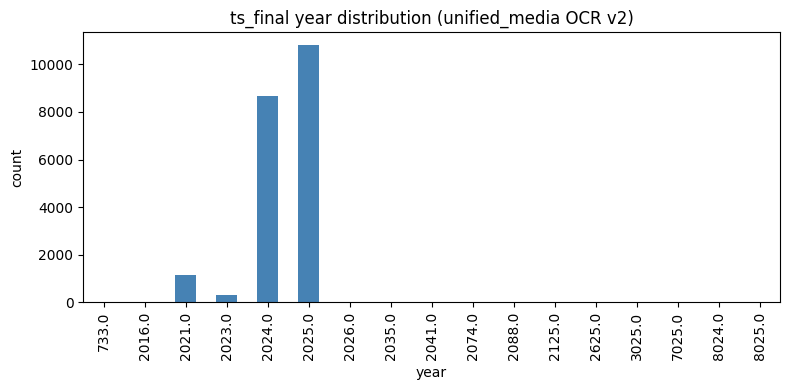

Saved plot: /home/chengwei/boartraining/HackMITChina2026/eda_outputs/plots/ocr_v2_final_year_distribution.png


In [8]:
# Validation summary: years should concentrate in 2024–2025 after rules
if "ocr_skipped" in out.columns:
    print("OCR skipped (EXIF year in {2024,2025}):", int(out["ocr_skipped"].sum()), "/", len(out))
vc = out["validation_status"].value_counts()
print("validation_status:")
print(vc)

fy = out["final_year"].value_counts().sort_index()
print("\nfinal_year counts:")
print(fy)

in_window = out["final_year"].isin(list(EXPECTED_YEARS)).sum()
print(f"\nShare final_year in {{2024,2025}}: {in_window / max(len(out),1):.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
fy.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("ts_final year distribution (unified_media OCR v2)")
ax.set_xlabel("year")
ax.set_ylabel("count")
plt.tight_layout()
fp = OUT_DIR / "plots" / "ocr_v2_final_year_distribution.png"
fp.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(fp, dpi=140)
plt.show()
print("Saved plot:", fp)


## 5) Visualizations — station (`station_id`) and time (`ts_final`)

Uses **`ts_final`** as the ecological timestamp (after EXIF-first + OCR merge rules).

Figures are saved under **`eda_outputs/plots/`** with prefix **`ocr_v2_viz_`**.

Run this section after the export cell, or restart the kernel and run only the setup paths cell plus the code cell below (it loads `unified_media_ocr_v2.csv` if `out` is undefined).

rows: 25701 | with ts_final: 18140


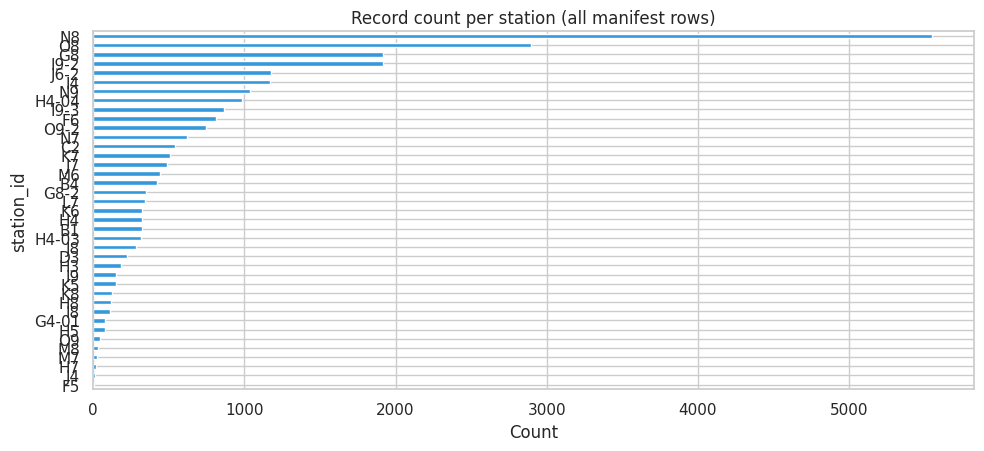

Saved: /home/chengwei/boartraining/HackMITChina2026/eda_outputs/plots/ocr_v2_viz_station_counts.png


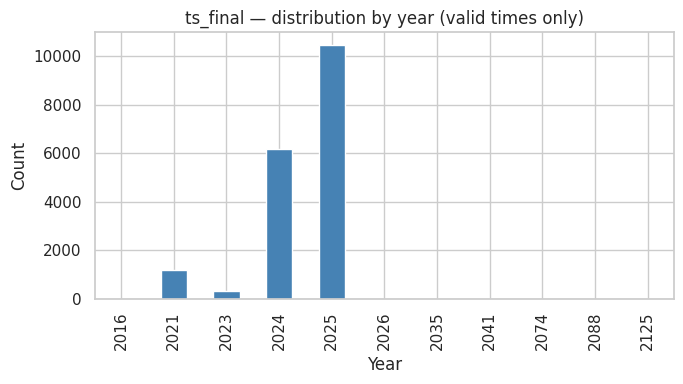

Saved: /home/chengwei/boartraining/HackMITChina2026/eda_outputs/plots/ocr_v2_viz_final_year.png


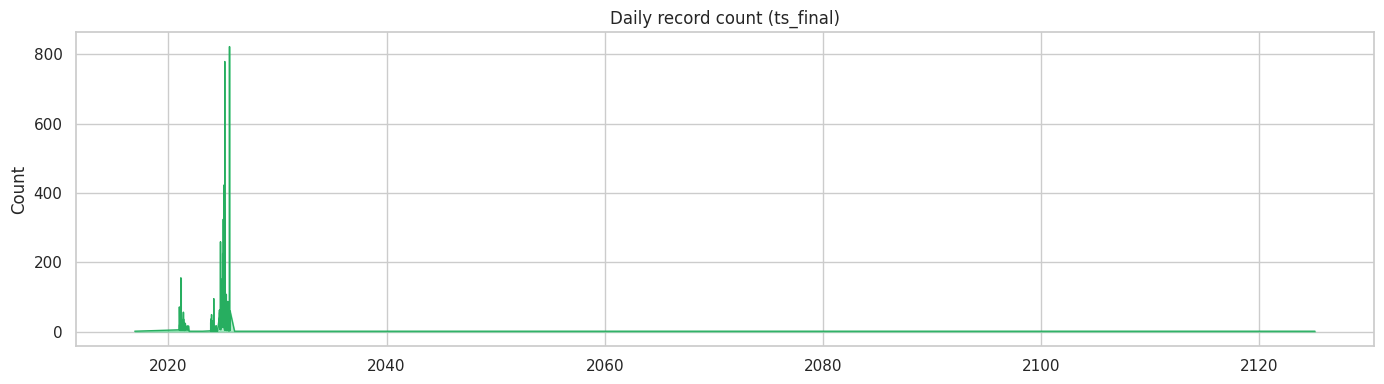

Saved: /home/chengwei/boartraining/HackMITChina2026/eda_outputs/plots/ocr_v2_viz_daily_counts.png


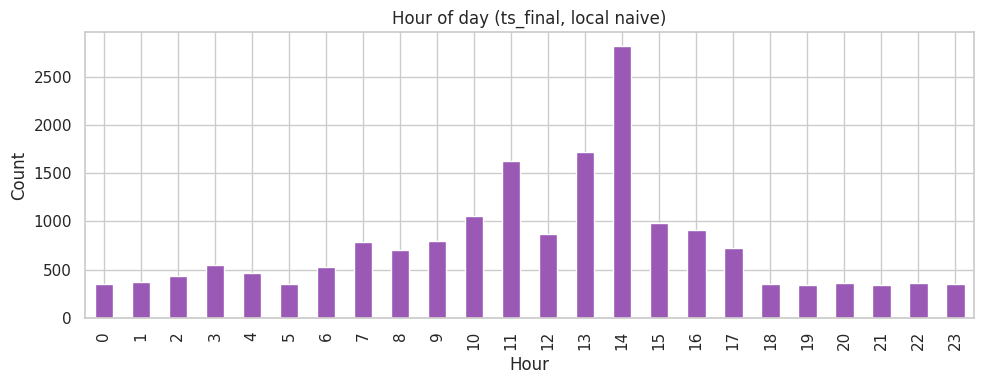

Saved: /home/chengwei/boartraining/HackMITChina2026/eda_outputs/plots/ocr_v2_viz_hour_histogram.png


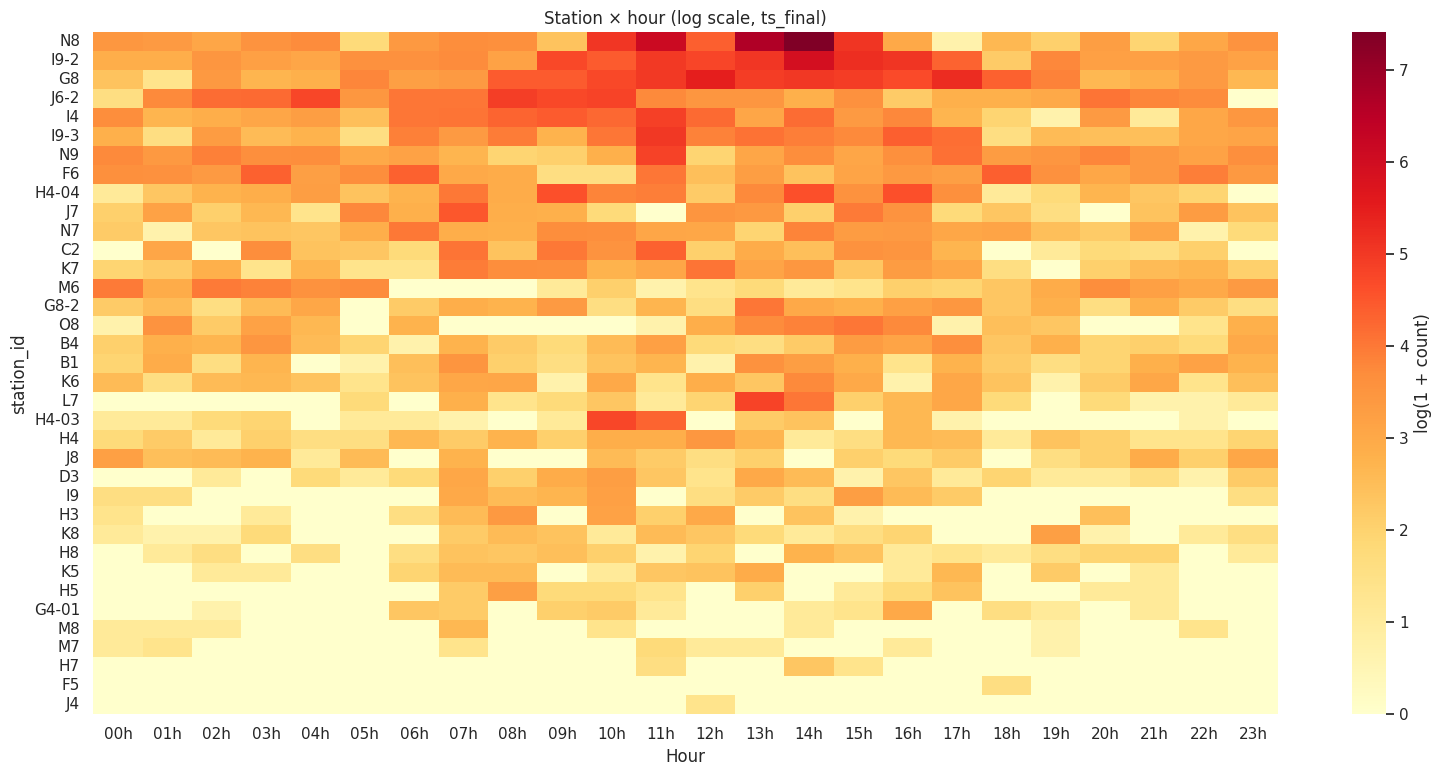

Saved: /home/chengwei/boartraining/HackMITChina2026/eda_outputs/plots/ocr_v2_viz_station_hour_heatmap.png


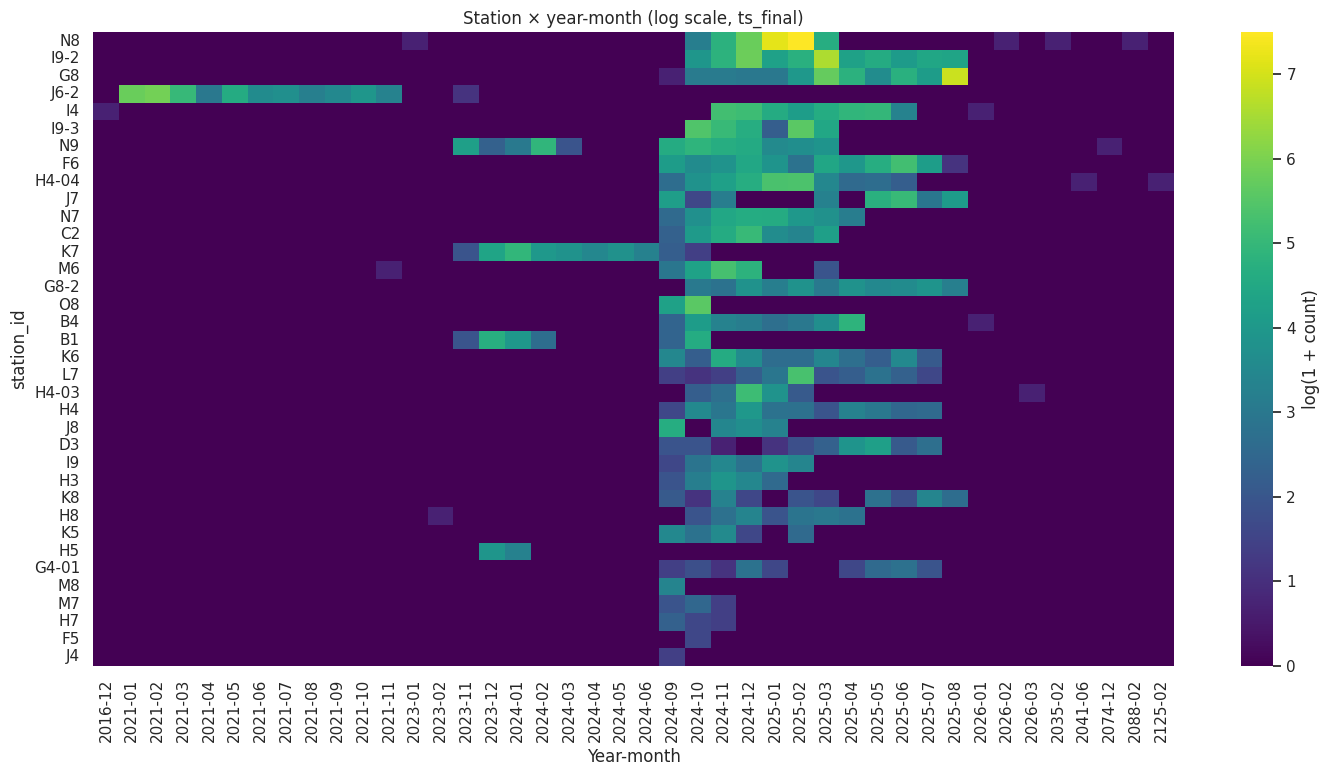

Saved: /home/chengwei/boartraining/HackMITChina2026/eda_outputs/plots/ocr_v2_viz_station_yearmonth_heatmap.png


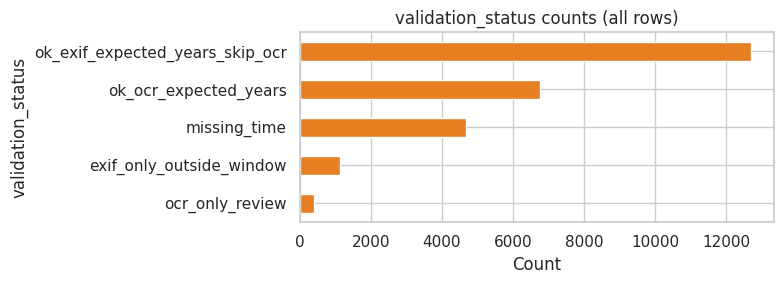

Saved: /home/chengwei/boartraining/HackMITChina2026/eda_outputs/plots/ocr_v2_viz_validation_status.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

PLOT_DIR = OUT_DIR / "plots"
PREFIX = "ocr_v2_viz_"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

try:
    viz = out.copy()
except NameError:
    viz = pd.read_csv(OUT_CSV, low_memory=False)

viz["station_id"] = viz["station_id"].astype(str).str.strip()
for c in ("ts_final", "ts_ocr", "ts_exif"):
    if c in viz.columns:
        viz[c] = pd.to_datetime(viz[c], errors="coerce")

viz["has_ts_final"] = viz["ts_final"].notna()
viz["hour"] = viz["ts_final"].dt.hour
viz["date"] = viz["ts_final"].dt.normalize()
viz["year_month"] = viz["ts_final"].dt.to_period("M").astype(str)

print("rows:", len(viz), "| with ts_final:", int(viz["has_ts_final"].sum()))

vd = viz.loc[viz["has_ts_final"]].copy()
if len(vd) == 0:
    print("No valid ts_final — only station count plot will be meaningful.")

# --- A) Records per station (all rows) ---
st_counts = viz.groupby("station_id").size().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, max(4, len(st_counts) * 0.12)))
st_counts.plot(kind="barh", ax=ax, color="#3498db")
ax.set_title("Record count per station (all manifest rows)")
ax.set_xlabel("Count")
ax.set_ylabel("station_id")
plt.tight_layout()
fa = PLOT_DIR / f"{PREFIX}station_counts.png"
fig.savefig(fa, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", fa)

# --- B–F) Time distributions (need valid ts_final) ---
if len(vd) == 0:
    print("Skipping time plots B–F (no valid ts_final).")
else:
    # --- B) ts_final year distribution ---
    fy = vd["ts_final"].dt.year.value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(7, 4))
    fy.plot(kind="bar", ax=ax, color="steelblue")
    ax.set_title("ts_final — distribution by year (valid times only)")
    ax.set_xlabel("Year")
    ax.set_ylabel("Count")
    plt.tight_layout()
    fb = PLOT_DIR / f"{PREFIX}final_year.png"
    fig.savefig(fb, dpi=160, bbox_inches="tight")
    plt.show()
    print("Saved:", fb)

    # --- C) Daily totals ---
    daily = vd.groupby("date").size().rename("n").reset_index()
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.fill_between(daily["date"], daily["n"], alpha=0.35, color="#2ecc71")
    ax.plot(daily["date"], daily["n"], color="#27ae60", lw=1)
    ax.set_title("Daily record count (ts_final)")
    ax.set_ylabel("Count")
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
    plt.tight_layout()
    fc = PLOT_DIR / f"{PREFIX}daily_counts.png"
    fig.savefig(fc, dpi=160, bbox_inches="tight")
    plt.show()
    print("Saved:", fc)

    # --- D) Hour-of-day histogram ---
    fig, ax = plt.subplots(figsize=(10, 4))
    vd["hour"].dropna().astype(int).value_counts().sort_index().reindex(
        range(24), fill_value=0
    ).plot(kind="bar", ax=ax, color="#9b59b6")
    ax.set_title("Hour of day (ts_final, local naive)")
    ax.set_xlabel("Hour")
    ax.set_ylabel("Count")
    plt.tight_layout()
    fd = PLOT_DIR / f"{PREFIX}hour_histogram.png"
    fig.savefig(fd, dpi=160, bbox_inches="tight")
    plt.show()
    print("Saved:", fd)

    # --- E) Heatmap station × hour ---
    order = (
        vd.groupby("station_id")
        .size()
        .sort_values(ascending=False)
        .index.astype(str)
        .tolist()
    )
    piv_h = (
        vd.groupby(["station_id", "hour"])
        .size()
        .unstack(fill_value=0)
        .reindex(order)
    )
    piv_h = piv_h.reindex(columns=range(24), fill_value=0)
    piv_h.columns = [f"{h:02d}h" for h in range(24)]

    fig, ax = plt.subplots(figsize=(16, max(5, len(order) * 0.22)))
    sns.heatmap(
        np.log1p(piv_h),
        cmap="YlOrRd",
        ax=ax,
        cbar_kws={"label": "log(1 + count)"},
        linewidths=0,
    )
    ax.set_title("Station × hour (log scale, ts_final)")
    ax.set_xlabel("Hour")
    ax.set_ylabel("station_id")
    plt.tight_layout()
    fe = PLOT_DIR / f"{PREFIX}station_hour_heatmap.png"
    fig.savefig(fe, dpi=160, bbox_inches="tight")
    plt.show()
    print("Saved:", fe)

    # --- F) Heatmap station × year-month ---
    piv_m = (
        vd.groupby(["station_id", "year_month"])
        .size()
        .unstack(fill_value=0)
        .reindex(order)
    )
    if piv_m.shape[1] > 0:
        piv_m = piv_m[sorted(piv_m.columns)]
        fig, ax = plt.subplots(
            figsize=(max(12, piv_m.shape[1] * 0.35), max(5, len(order) * 0.22))
        )
        sns.heatmap(
            np.log1p(piv_m),
            cmap="viridis",
            ax=ax,
            cbar_kws={"label": "log(1 + count)"},
            linewidths=0,
        )
        ax.set_title("Station × year-month (log scale, ts_final)")
        ax.set_xlabel("Year-month")
        ax.set_ylabel("station_id")
        plt.tight_layout()
        ff = PLOT_DIR / f"{PREFIX}station_yearmonth_heatmap.png"
        fig.savefig(ff, dpi=160, bbox_inches="tight")
        plt.show()
        print("Saved:", ff)
    else:
        print("Skip year-month heatmap: no month columns.")

# --- G) Validation status mix (overall) ---
if "validation_status" in viz.columns:
    vs = viz["validation_status"].value_counts()
    fig, ax = plt.subplots(figsize=(8, max(3, 0.35 * len(vs))))
    vs.sort_values(ascending=True).plot(kind="barh", ax=ax, color="#e67e22")
    ax.set_title("validation_status counts (all rows)")
    ax.set_xlabel("Count")
    plt.tight_layout()
    fg = PLOT_DIR / f"{PREFIX}validation_status.png"
    fig.savefig(fg, dpi=160, bbox_inches="tight")
    plt.show()
    print("Saved:", fg)
